# Air Quality Index (AQI) - Exploratory Data Analysis

## Comprehensive Analysis of Air Quality Data Across Indian Cities

This notebook performs a detailed exploratory data analysis on the AQI dataset containing pollution measurements from various Indian cities.

**Dataset Information:**
- Source: city_day.csv
- Time Period: 2015 onwards
- Parameters: PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene
- Cities: Multiple Indian cities

---

## 1. Import Required Libraries

In [3]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, skew, kurtosis

# Date/time handling
from datetime import datetime, timedelta

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load the Dataset

In [4]:
# Load the city_day.csv dataset
df = pd.read_csv('Dataset/city_day.csv')

# Display basic information
print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"\nMemory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

# Display first few rows
df.head(10)

Dataset Shape: (29531, 16)
Total Records: 29,531
Total Features: 16

Memory Usage: 3.60 MB


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,46.51,5.42,10.83,1.93,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,33.47,0.00,0.00,0.00,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,31.89,0.00,0.00,0.00,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,25.75,0.00,0.00,0.00,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,7.04,0.00,NaN,NaN,8.29,4.55,0.00,0.00,0.00,NaN,NaN


## 3. Data Overview and Structure

In [5]:
# Dataset information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [6]:
# Column names and data types
print("\n" + "=" * 80)
print("COLUMN DATA TYPES")
print("=" * 80)
for col in df.columns:
    print(f"{col:<20} : {str(df[col].dtype):<15} | Unique: {df[col].nunique():>6}")


COLUMN DATA TYPES
City                 : object          | Unique:     26
Date                 : object          | Unique:   2009
PM2.5                : float64         | Unique:  11716
PM10                 : float64         | Unique:  12571
NO                   : float64         | Unique:   5776
NO2                  : float64         | Unique:   7404
NOx                  : float64         | Unique:   8156
NH3                  : float64         | Unique:   5922
CO                   : float64         | Unique:   1779
SO2                  : float64         | Unique:   4761
O3                   : float64         | Unique:   7699
Benzene              : float64         | Unique:   1873
Toluene              : float64         | Unique:   3608
Xylene               : float64         | Unique:   1561
AQI                  : float64         | Unique:    829
AQI_Bucket           : object          | Unique:      6


In [7]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter

print("✅ Date features extracted successfully!")
print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total Days: {(df['Date'].max() - df['Date'].min()).days:,} days")

✅ Date features extracted successfully!

Date Range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00
Total Days: 2,008 days


## 4. Missing Value Analysis

In [8]:
# Calculate missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
print(missing_data.to_string(index=False))
print(f"\nTotal Missing Values: {df.isnull().sum().sum():,}")

MISSING VALUES ANALYSIS
    Column  Missing_Count  Missing_Percentage
    Xylene          18109               61.32
      PM10          11140               37.72
       NH3          10328               34.97
   Toluene           8041               27.23
   Benzene           5623               19.04
       AQI           4681               15.85
AQI_Bucket           4681               15.85
     PM2.5           4598               15.57
       NOx           4185               14.17
        O3           4022               13.62
       SO2           3854               13.05
       NO2           3585               12.14
        NO           3582               12.13
        CO           2059                6.97

Total Missing Values: 88,488


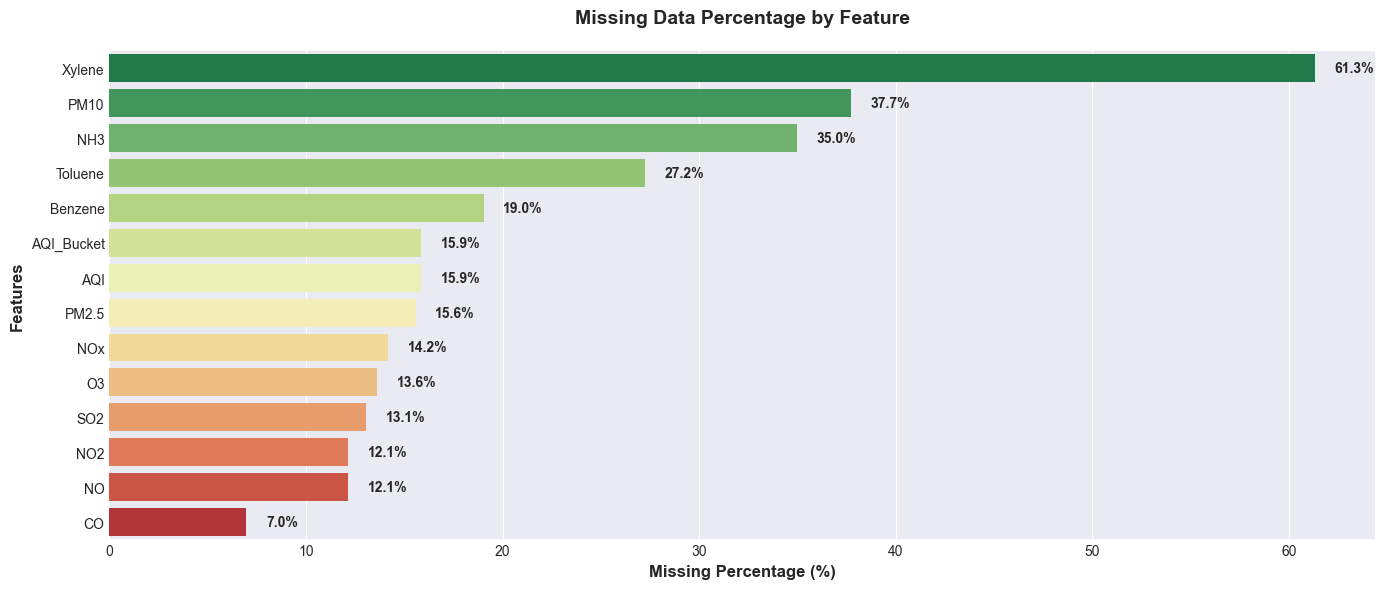

In [9]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(14, 6))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='RdYlGn_r', ax=ax)
ax.set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Missing Data Percentage by Feature', fontsize=14, fontweight='bold', pad=20)

# Add percentage labels
for i, v in enumerate(missing_pct.values):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Statistical Summary

In [10]:
# Descriptive statistics for pollutants
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
print("=" * 120)
print("STATISTICAL SUMMARY OF POLLUTANTS")
print("=" * 120)
df[pollutants].describe().T.round(2)

STATISTICAL SUMMARY OF POLLUTANTS


,count,mean,std,min,25%,50%,75%,max
PM2.5,24933.00,67.45,64.66,0.04,28.82,48.57,80.59,949.99
PM10,18391.00,118.13,90.61,0.01,56.26,95.68,149.74,1000.00
NO,25949.00,17.57,22.79,0.02,5.63,9.89,19.95,390.68
NO2,25946.00,28.56,24.47,0.01,11.75,21.69,37.62,362.21
NOx,25346.00,32.31,31.65,0.00,12.82,23.52,40.13,467.63
NH3,19203.00,23.48,25.68,0.01,8.58,15.85,30.02,352.89
CO,27472.00,2.25,6.96,0.00,0.51,0.89,1.45,175.81
SO2,25677.00,14.53,18.13,0.01,5.67,9.16,15.22,193.86
O3,25509.00,34.49,21.69,0.01,18.86,30.84,45.57,257.73
Benzene,23908.00,3.28,15.81,0.00,0.12,1.07,3.08,455.03


In [11]:
# Additional statistics
stats_df = pd.DataFrame({
    'Mean': df[pollutants].mean(),
    'Median': df[pollutants].median(),
    'Std': df[pollutants].std(),
    'Skewness': df[pollutants].skew(),
    'Kurtosis': df[pollutants].kurtosis(),
    'CV (%)': (df[pollutants].std() / df[pollutants].mean() * 100)
}).round(2)

print("\n" + "=" * 120)
print("ADVANCED STATISTICS")
print("=" * 120)
stats_df


ADVANCED STATISTICS


,Mean,Median,Std,Skewness,Kurtosis,CV (%)
PM2.5,67.45,48.57,64.66,3.37,21.13,95.86
PM10,118.13,95.68,90.61,2.05,6.75,76.70
NO,17.57,9.89,22.79,3.88,25.16,129.65
NO2,28.56,21.69,24.47,2.46,11.21,85.69
NOx,32.31,23.52,31.65,2.57,10.84,97.95
NH3,23.48,15.85,25.68,4.08,27.96,109.37
CO,2.25,0.89,6.96,8.88,109.49,309.65
SO2,14.53,9.16,18.13,4.08,22.07,124.79
O3,34.49,30.84,21.69,1.33,3.43,62.90
Benzene,3.28,1.07,15.81,21.30,530.17,481.92


## 6. City-wise Analysis

In [12]:
# Number of cities
print(f"Total Number of Cities: {df['City'].nunique()}")
print(f"\nCities List:")
print(", ".join(sorted(df['City'].unique())))

Total Number of Cities: 26

Cities List:
Ahmedabad, Aizawl, Amaravati, Amritsar, Bengaluru, Bhopal, Brajrajnagar, Chandigarh, Chennai, Coimbatore, Delhi, Ernakulam, Gurugram, Guwahati, Hyderabad, Jaipur, Jorapokhar, Kochi, Kolkata, Lucknow, Mumbai, Patna, Shillong, Talcher, Thiruvananthapuram, Visakhapatnam


In [13]:
# Records per city
city_counts = df['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Record_Count']

print("\n" + "=" * 80)
print("TOP 20 CITIES BY NUMBER OF RECORDS")
print("=" * 80)
print(city_counts.head(20).to_string(index=False))


TOP 20 CITIES BY NUMBER OF RECORDS
              City  Record_Count
         Ahmedabad          2009
             Delhi          2009
            Mumbai          2009
         Bengaluru          2009
           Lucknow          2009
           Chennai          2009
         Hyderabad          2006
             Patna          1858
          Gurugram          1679
     Visakhapatnam          1462
          Amritsar          1221
        Jorapokhar          1169
            Jaipur          1114
Thiruvananthapuram          1112
         Amaravati           951
      Brajrajnagar           938
           Talcher           925
           Kolkata           814
          Guwahati           502
        Coimbatore           386


In [14]:
# Visualize top 20 cities
fig = px.bar(city_counts.head(20), 
             x='Record_Count', 
             y='City', 
             orientation='h',
             title='Top 20 Cities by Number of Records',
             labels={'Record_Count': 'Number of Records', 'City': 'City'},
             color='Record_Count',
             color_continuous_scale='Blues')

fig.update_layout(height=600, showlegend=False, yaxis={'categoryorder':'total ascending'})
fig.show()

## 7. AQI Analysis

In [15]:
# AQI Categories distribution
print("=" * 80)
print("AQI BUCKET DISTRIBUTION")
print("=" * 80)

aqi_dist = df['AQI_Bucket'].value_counts().reset_index()
aqi_dist.columns = ['AQI_Category', 'Count']
aqi_dist['Percentage'] = (aqi_dist['Count'] / aqi_dist['Count'].sum() * 100).round(2)
print(aqi_dist.to_string(index=False))

AQI BUCKET DISTRIBUTION
AQI_Category  Count  Percentage
    Moderate   8829       35.53
Satisfactory   8224       33.09
        Poor   2781       11.19
   Very Poor   2337        9.40
        Good   1341        5.40
      Severe   1338        5.38


In [16]:
# AQI Distribution Visualization
aqi_colors = {
    'Good': '#00e400',
    'Satisfactory': '#ffff00',
    'Moderate': '#ff7e00',
    'Poor': '#ff0000',
    'Very Poor': '#8f3f97',
    'Severe': '#7e0023'
}

fig = go.Figure(data=[go.Pie(
    labels=aqi_dist['AQI_Category'],
    values=aqi_dist['Count'],
    hole=0.4,
    marker_colors=[aqi_colors.get(cat, '#cccccc') for cat in aqi_dist['AQI_Category']],
    textinfo='label+percent',
    textfont_size=12
)])

fig.update_layout(
    title='AQI Category Distribution',
    height=500,
    showlegend=True
)
fig.show()

In [17]:
# AQI Statistics
print("\n" + "=" * 80)
print("AQI STATISTICS")
print("=" * 80)
print(f"Mean AQI: {df['AQI'].mean():.2f}")
print(f"Median AQI: {df['AQI'].median():.2f}")
print(f"Min AQI: {df['AQI'].min():.2f}")
print(f"Max AQI: {df['AQI'].max():.2f}")
print(f"Std Dev: {df['AQI'].std():.2f}")


AQI STATISTICS
Mean AQI: 166.46
Median AQI: 118.00
Min AQI: 13.00
Max AQI: 2049.00
Std Dev: 140.70


In [18]:
# AQI distribution histogram
fig = px.histogram(df.dropna(subset=['AQI']), 
                   x='AQI', 
                   nbins=100,
                   title='AQI Distribution',
                   labels={'AQI': 'Air Quality Index'},
                   color_discrete_sequence=['#3b82f6'])

fig.add_vline(x=df['AQI'].mean(), line_dash="dash", line_color="red", 
              annotation_text=f"Mean: {df['AQI'].mean():.1f}")
fig.add_vline(x=df['AQI'].median(), line_dash="dash", line_color="green", 
              annotation_text=f"Median: {df['AQI'].median():.1f}")

fig.update_layout(height=500)
fig.show()

## 8. Top 10 Most Polluted Cities

In [19]:
# Calculate average AQI per city
city_aqi = df.groupby('City')['AQI'].agg(['mean', 'median', 'max', 'min', 'std', 'count']).round(2)
city_aqi = city_aqi.sort_values('mean', ascending=False)

print("=" * 100)
print("TOP 10 MOST POLLUTED CITIES (by Average AQI)")
print("=" * 100)
print(city_aqi.head(10).to_string())

TOP 10 MOST POLLUTED CITIES (by Average AQI)
               mean  median     max   min    std  count
City                                                   
Ahmedabad    452.12  384.50 2049.00 48.00 311.73   1334
Delhi        259.49  257.00  716.00 29.00 119.54   1999
Patna        240.78  215.00  619.00 53.00 122.34   1459
Gurugram     225.12  208.00  891.00 38.00 119.94   1453
Lucknow      217.97  198.00  707.00 39.00 116.96   1893
Talcher      172.89  128.50  570.00 13.00 104.87    698
Jorapokhar   159.25  133.00  604.00 27.00  84.70    771
Brajrajnagar 150.28  122.00  355.00 22.00  70.37    713
Kolkata      140.57   94.00  475.00 26.00 104.49    754
Guwahati     140.11   98.00  956.00 25.00 112.76    495


In [20]:
# Visualize top 10 polluted cities
top_10_cities = city_aqi.head(10).reset_index()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=top_10_cities['City'],
    y=top_10_cities['mean'],
    name='Mean AQI',
    marker_color='indianred'
))

fig.update_layout(
    title='Top 10 Most Polluted Cities (Average AQI)',
    xaxis_title='City',
    yaxis_title='Average AQI',
    height=500,
    xaxis_tickangle=-45
)
fig.show()

In [21]:
# Top 10 cleanest cities
print("\n" + "=" * 100)
print("TOP 10 CLEANEST CITIES (by Average AQI)")
print("=" * 100)
print(city_aqi.tail(10).to_string())


TOP 10 CLEANEST CITIES (by Average AQI)
                     mean  median    max   min   std  count
City                                                       
Mumbai             105.35   91.00 307.00 40.00 47.41    775
Kochi              104.28   99.00 277.00 51.00 34.05    158
Chandigarh          96.50   82.00 335.00 26.00 57.18    299
Amaravati           95.30   78.00 312.00 24.00 56.06    841
Bengaluru           94.32   86.00 352.00 20.00 39.91   1910
Ernakulam           92.36   94.00 180.00 55.00 19.39    153
Thiruvananthapuram  75.88   68.00 230.00 32.00 28.40   1052
Coimbatore          73.02   75.00 120.00 26.00 18.06    344
Shillong            53.80   48.00 182.00 14.00 28.40    205
Aizawl              34.77   23.00  92.00 18.00 19.97    111


## 9. Pollutant Distribution Analysis

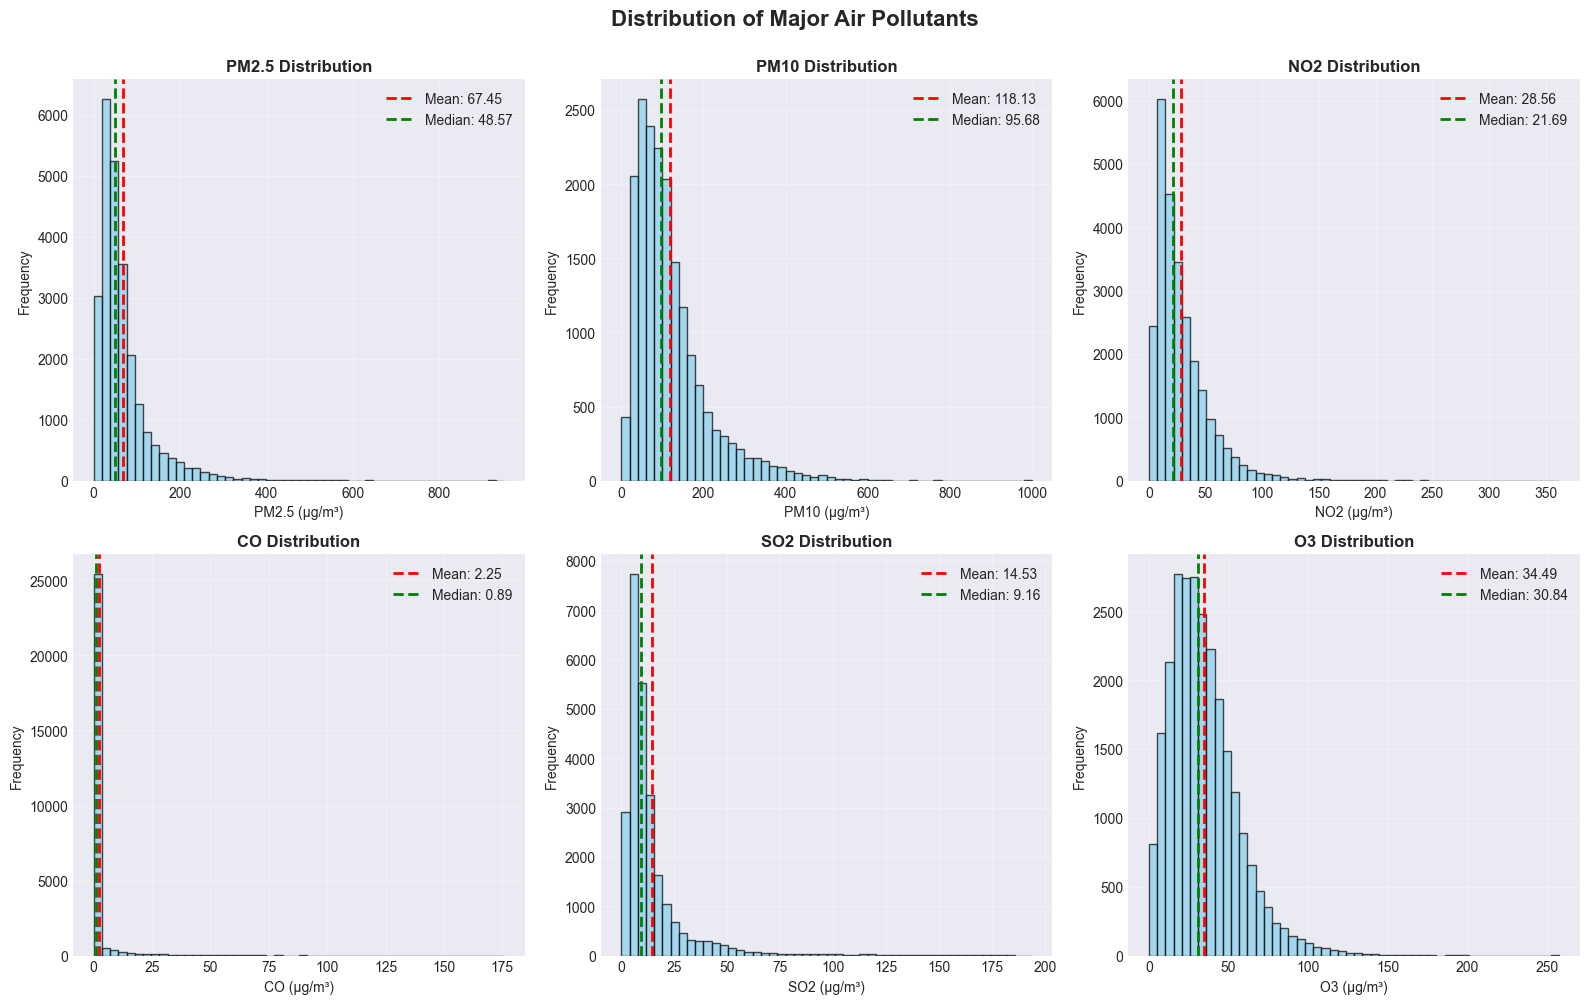

In [22]:
# Distribution plots for major pollutants
major_pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, pollutant in enumerate(major_pollutants):
    data = df[pollutant].dropna()
    axes[idx].hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
    axes[idx].axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data.median():.2f}')
    axes[idx].set_title(f'{pollutant} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(f'{pollutant} (µg/m³)', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Distribution of Major Air Pollutants', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

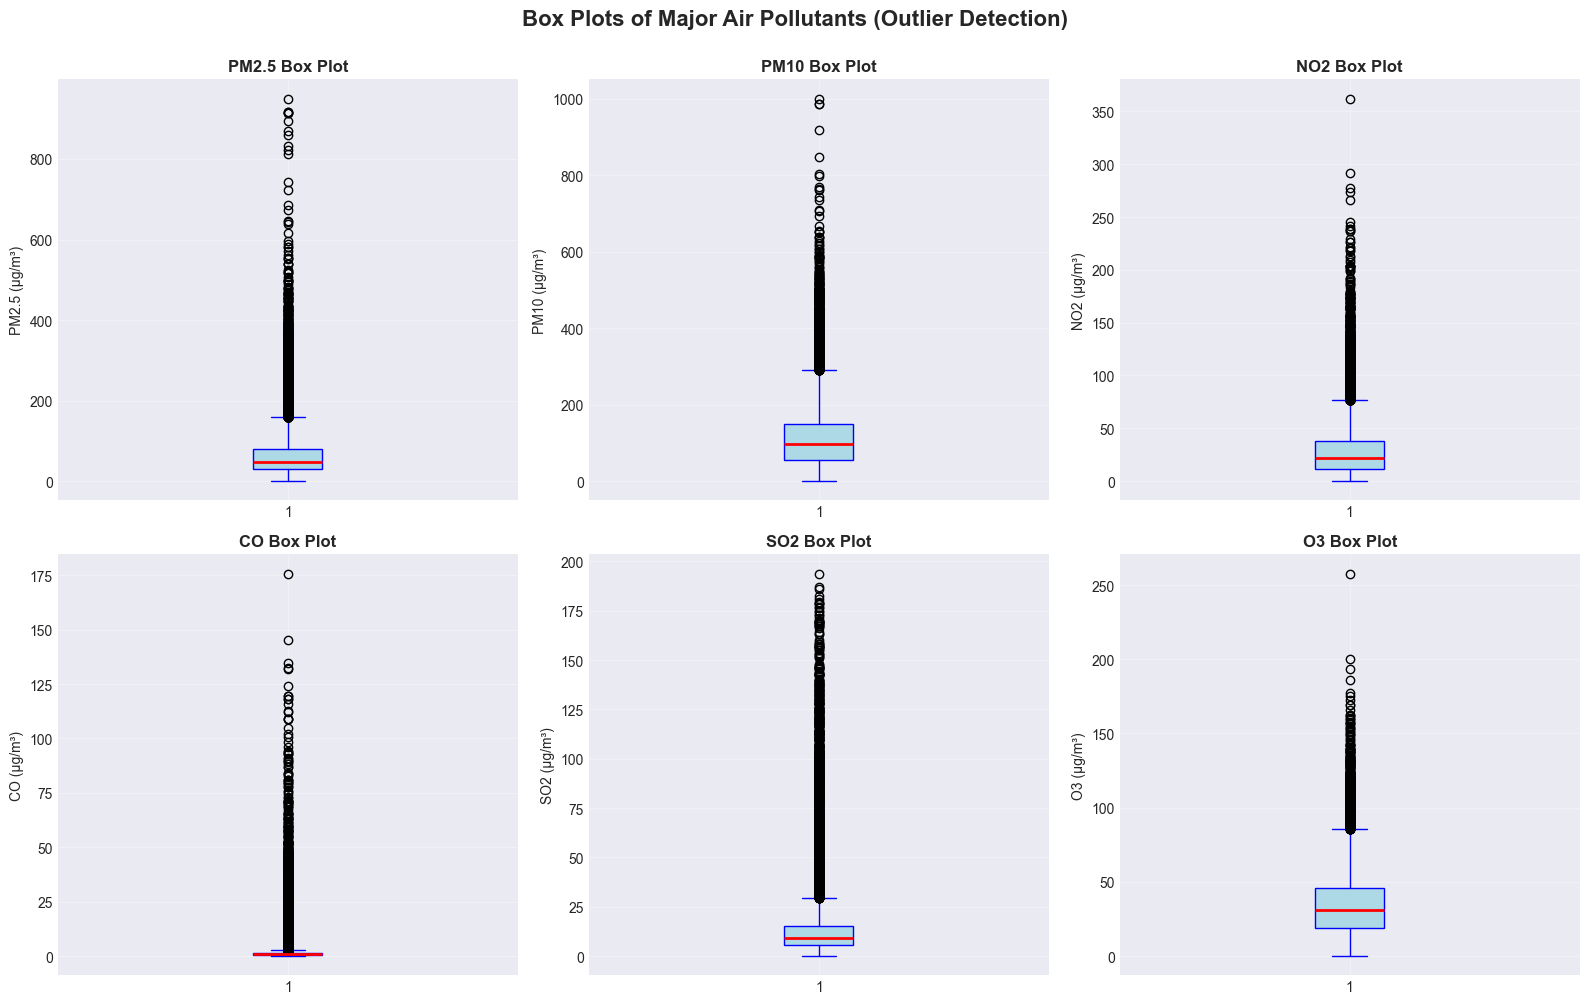

In [23]:
# Box plots for pollutants
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, pollutant in enumerate(major_pollutants):
    data = df[pollutant].dropna()
    axes[idx].boxplot(data, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='blue'),
                      whiskerprops=dict(color='blue'),
                      capprops=dict(color='blue'),
                      medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(f'{pollutant} Box Plot', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(f'{pollutant} (µg/m³)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Box Plots of Major Air Pollutants (Outlier Detection)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 10. Correlation Analysis

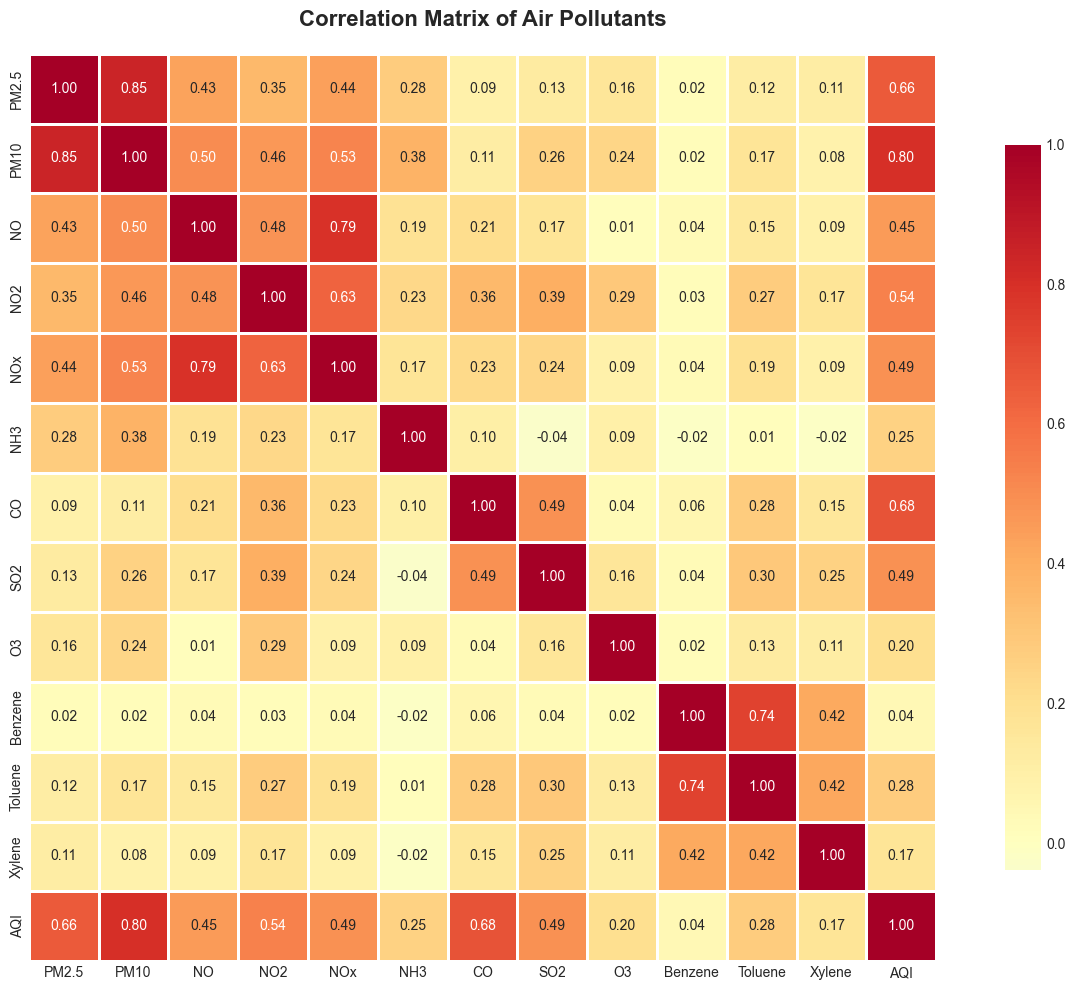

In [24]:
# Correlation matrix
correlation_matrix = df[pollutants].corr()

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlBu_r', 
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix of Air Pollutants', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [25]:
# Top correlations with AQI
aqi_correlations = correlation_matrix['AQI'].sort_values(ascending=False).drop('AQI')

print("=" * 80)
print("CORRELATION WITH AQI")
print("=" * 80)
for pollutant, corr in aqi_correlations.items():
    print(f"{pollutant:<15} : {corr:>6.3f}")

CORRELATION WITH AQI
PM10            :  0.803
CO              :  0.683
PM2.5           :  0.659
NO2             :  0.537
SO2             :  0.491
NOx             :  0.486
NO              :  0.452
Toluene         :  0.280
NH3             :  0.252
O3              :  0.199
Xylene          :  0.166
Benzene         :  0.044


In [26]:
# Interactive heatmap with plotly
fig = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.columns,
    colorscale='RdBu_r',
    zmid=0,
    text=correlation_matrix.values,
    texttemplate='%{text:.2f}',
    textfont={"size": 10},
    colorbar=dict(title="Correlation")
))

fig.update_layout(
    title='Interactive Correlation Heatmap',
    height=700,
    width=800
)
fig.show()

## 11. Temporal Trends

In [27]:
# Yearly trend
yearly_aqi = df.groupby('Year')['AQI'].mean().reset_index()

fig = px.line(yearly_aqi, 
              x='Year', 
              y='AQI',
              title='Average AQI Trend Over Years',
              markers=True,
              line_shape='spline')

fig.update_traces(line_color='#3b82f6', line_width=3, marker_size=10)
fig.update_layout(height=500, hovermode='x unified')
fig.show()

In [28]:
# Monthly trend (aggregated across all years)
monthly_aqi = df.groupby('Month')['AQI'].mean().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_aqi['Month_Name'] = monthly_aqi['Month'].map(lambda x: month_names[x-1])

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_aqi['Month_Name'],
    y=monthly_aqi['AQI'],
    mode='lines+markers',
    name='AQI',
    line=dict(color='firebrick', width=3),
    marker=dict(size=10, color='firebrick')
))

fig.update_layout(
    title='Average AQI by Month (Seasonal Pattern)',
    xaxis_title='Month',
    yaxis_title='Average AQI',
    height=500,
    hovermode='x unified'
)
fig.show()

In [29]:
# Day of week analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_aqi = df.groupby('DayOfWeek')['AQI'].mean().reindex(day_order).reset_index()

fig = px.bar(dow_aqi, 
             x='DayOfWeek', 
             y='AQI',
             title='Average AQI by Day of Week',
             color='AQI',
             color_continuous_scale='Reds')

fig.update_layout(height=500, showlegend=False)
fig.show()

## 12. City Comparison (Top 6 Cities)

In [30]:
# Select top 6 cities for detailed comparison
top_cities = ['Delhi', 'Mumbai', 'Bengaluru', 'Kolkata', 'Chennai', 'Hyderabad']
cities_df = df[df['City'].isin(top_cities)].copy()

# Average pollutants by city
city_pollutants = cities_df.groupby('City')[major_pollutants].mean().round(2)

print("=" * 100)
print("POLLUTANT LEVELS - TOP 6 CITIES")
print("=" * 100)
print(city_pollutants.to_string())

POLLUTANT LEVELS - TOP 6 CITIES
           PM2.5   PM10   NO2   CO   SO2    O3
City                                          
Bengaluru  35.82  83.24 28.00 1.84  5.52 32.87
Chennai    50.43  62.83 16.86 1.07  7.88 32.44
Delhi     117.20 232.81 50.79 1.98 15.90 51.32
Hyderabad  47.04  91.93 28.39 0.59  9.17 33.61
Kolkata    64.36 115.63 40.40 0.80  8.39 30.66
Mumbai     35.20  96.75 25.56 0.57 15.20 33.06


In [31]:
# Radar chart for city comparison
fig = go.Figure()

for city in top_cities:
    if city in city_pollutants.index:
        values = city_pollutants.loc[city].values.tolist()
        values += values[:1]  # Complete the circle
        
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=major_pollutants + [major_pollutants[0]],
            fill='toself',
            name=city
        ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    showlegend=True,
    title='Pollutant Levels Comparison - Top 6 Cities',
    height=600
)
fig.show()

In [32]:
# AQI trends for top cities
cities_yearly = cities_df.groupby(['Year', 'City'])['AQI'].mean().reset_index()

fig = px.line(cities_yearly, 
              x='Year', 
              y='AQI', 
              color='City',
              title='AQI Trends Over Years - Top 6 Cities',
              markers=True,
              line_shape='spline')

fig.update_layout(height=600, hovermode='x unified')
fig.show()

## 13. Seasonal Analysis

In [33]:
# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Monsoon'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

# Seasonal AQI statistics
seasonal_aqi = df.groupby('Season')['AQI'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
seasonal_order = ['Winter', 'Spring', 'Monsoon', 'Autumn']
seasonal_aqi = seasonal_aqi.reindex(seasonal_order)

print("=" * 80)
print("SEASONAL AQI STATISTICS")
print("=" * 80)
print(seasonal_aqi.to_string())

SEASONAL AQI STATISTICS
          mean  median    std   min     max
Season                                     
Winter  220.61  171.00 157.30 26.00 2049.00
Spring  147.67  115.00 116.47 14.00 1459.00
Monsoon 115.66   90.00  97.32 16.00 1842.00
Autumn  183.91  122.00 162.46 13.00 1747.00


In [34]:
# Seasonal comparison boxplot
fig = px.box(df[df['Season'].notna()], 
             x='Season', 
             y='AQI',
             title='AQI Distribution by Season',
             color='Season',
             category_orders={'Season': seasonal_order})

fig.update_layout(height=600, showlegend=False)
fig.show()

## 14. Key Insights and Summary

In [35]:
print("=" * 100)
print("KEY INSIGHTS FROM AQI DATA ANALYSIS")
print("=" * 100)

insights = [
    f"1. Dataset contains {df.shape[0]:,} records from {df['City'].nunique()} cities",
    f"2. Data spans from {df['Date'].min().date()} to {df['Date'].max().date()}",
    f"3. Average AQI across all cities: {df['AQI'].mean():.2f}",
    f"4. Most polluted city (by avg AQI): {city_aqi.index[0]} ({city_aqi.iloc[0]['mean']:.2f})",
    f"5. Cleanest city (by avg AQI): {city_aqi.index[-1]} ({city_aqi.iloc[-1]['mean']:.2f})",
    f"6. Highest recorded AQI: {df['AQI'].max():.2f}",
    f"7. PM2.5 shows strongest correlation with AQI: {correlation_matrix.loc['PM2.5', 'AQI']:.3f}",
    f"8. Worst season for air quality: {seasonal_aqi['mean'].idxmax()} (Avg AQI: {seasonal_aqi['mean'].max():.2f})",
    f"9. Best season for air quality: {seasonal_aqi['mean'].idxmin()} (Avg AQI: {seasonal_aqi['mean'].min():.2f})",
    f"10. Missing data percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%"
]

for insight in insights:
    print(insight)

print("=" * 100)

KEY INSIGHTS FROM AQI DATA ANALYSIS
1. Dataset contains 29,531 records from 26 cities
2. Data spans from 2015-01-01 to 2020-07-01
3. Average AQI across all cities: 166.46
4. Most polluted city (by avg AQI): Ahmedabad (452.12)
5. Cleanest city (by avg AQI): Aizawl (34.77)
6. Highest recorded AQI: 2049.00
7. PM2.5 shows strongest correlation with AQI: 0.659
8. Worst season for air quality: Winter (Avg AQI: 220.61)
9. Best season for air quality: Monsoon (Avg AQI: 115.66)
10. Missing data percentage: 13.03%


## 15. Export Processed Data for Dashboard

In [36]:
# Export latest data for each city (for dashboard integration)
latest_data = df.sort_values('Date').groupby('City').tail(1)
latest_data_export = latest_data[['City', 'Date', 'PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI', 'AQI_Bucket']].copy()

# Export to JSON for easy integration
latest_data_export.to_json('latest_aqi_data.json', orient='records', date_format='iso', indent=2)

print("✅ Latest AQI data exported to 'latest_aqi_data.json'")
print(f"\nExported {len(latest_data_export)} cities")
print("\nSample data:")
latest_data_export.head()

✅ Latest AQI data exported to 'latest_aqi_data.json'

Exported 26 cities

Sample data:


,City,Date,PM2.5,PM10,NO2,CO,SO2,O3,AQI,AQI_Bucket
14580,Guwahati,2020-07-01,40.00,53.00,6.59,0.61,16.07,21.32,36.00,Good
2121,Aizawl,2020-07-01,4.49,5.39,0.07,0.02,2.07,3.39,20.00,Good
16586,Hyderabad,2020-07-01,26.83,66.50,27.18,0.43,6.07,13.20,48.00,Good
14078,Gurugram,2020-07-01,61.64,174.08,10.58,1.11,7.57,44.14,157.00,Moderate
17700,Jaipur,2020-07-01,58.79,103.68,10.88,0.54,5.19,53.68,70.00,Satisfactory


In [37]:
# Export summary statistics for top cities
top_cities_summary = city_aqi.head(10).reset_index()
top_cities_summary.to_json('top_cities_summary.json', orient='records', indent=2)

print("✅ Top cities summary exported to 'top_cities_summary.json'")

✅ Top cities summary exported to 'top_cities_summary.json'


---

## Conclusion

This comprehensive EDA has provided deep insights into India's air quality data:

**Key Findings:**
- Air quality varies significantly across Indian cities
- PM2.5 and PM10 are the primary contributors to AQI
- Clear seasonal patterns exist, with winter months typically showing worse air quality
- Major metropolitan areas show concerning pollution levels
- Strong correlations exist between certain pollutants

**Next Steps:**
1. Integrate real-time data with the dashboard
2. Build predictive models for AQI forecasting
3. Implement alert systems for hazardous conditions
4. Develop city-specific recommendations

---